[![OpenSD2026 - Belgium](../../assets/OpenSD_bannerlogo.jpg)](https://www.vub.be/en/event/opensd-summer-school-belgium)

Copyright © 2026 OpenSD2026 contributors. All rights reserved. The materials in this repository are provided for educational use only and may not be copied, redistributed, or modified without prior permission. See [LICENSE](../../LICENSE).

# *Outlines*

<img src="../../assets/Flowchart_FatigueAssessment.png" width="700">

# **Introduction**

We will be using loads from [WILLOW Norther Open Source Dataset](https://zenodo.org/records/11093262) for conducting this workshop

<img src="../../assets/Fig1_Norther_locaction.png" width="800">



There are various sensors installed on this turbine including accelerometers, strain gauges, fiber bragg gratings (FBGs)


<img src="../../assets/Sensor_Channels.png" width="700">


The list of SCADA parameters and the intervals for which the data is avaliable is also given as follows:

<img src="../../assets/SCADA_Operational_Data.png" width="500">



# *Loading Necessary Packages*

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Packages for handling and processing load data
import numpy as np

# Importing py_fatigue for load signals processing, fatigue damage and crack growth calculations
import py_fatigue as pf

#Packages for Plotting
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# *Geometry - Demo*

## *Static Extrapolation of Loads*
Till now, we have not considered any stress concentration factor in the cycle counting objects. These factors are important for **Stress Transformation to other locations**, **Incorporatethe effect of geometrical irregularities** and **include the effect of welds in the structure**

Consider a cantilever beam with varying cross-section and a point load applied at the tip as shown in Figure 2. The bending moment diagram in the cantilever beam is also shown.

The signal we have been using so far was stress signal measured at Section A-A of the given beam. We now have the measured stresses at Section A-A. From the bending moment diagram we notice that Section A-A is not the most critical location in the beam. At Section B-B, the bending moment is higher and there is a circumferential weld at that section as well. 

The stress signal needs to be transformed to Section B-B for calculation of the accumulated damage at Section B-B. Suppose from design, we know the bending moment diagram for the beam subjected to operation load **F** at the tip. The bending moment ratio at section A-A and section B-B is calculated as the load extrapolation factor shown in `Figure 2`. Similarly, the cross-sectional details at section A-A and section B-B are not the same. Thus, a stress extrapolation factor incorporating the effect of varying radius and second moment of area of the sections is calculated as shown in `Figure 2`. The circumferential weld at section B-B introduces a geometric irregularity and thus is accounted for a stress concentration factor. Finally a materials safety factor as per design is also included in the calculations.

<img src="../../assets/static_extrapolation.png" width="500">

<div align="center"><em>Figure 2: Bending Moment Diagram of a Beam Illustration and Static Extrapolation Factor</em></div>

All these factors are accumulated in a single **Stress Multiplication Factor** which is used for scaling the `cycle_count` objects and thus for accumulated damage calculation at Section B-B.

In [2]:
d_A = 4.5 # diameter at section A in m
t_A = 50  # thickness at section A in mm

In [3]:
d_B = 5  # diameter at section B in m
t_B = 55 # thickness at section B in mm

$$I = \frac{\pi (D^4 - d^4)}{64}$$

Where:
* $D$ is the outer diameter
* $d = D - 2 \cdot t$ is the inner diameter (with thickness $t$)

In [4]:
def moment_of_inertia(diameter, thickness):
    """
    Calculate the second moment of area (I) for a hollow circular section.
    
    Parameters
    ----------
    diameter : float
        Outer diameter in meters.
    thickness : float
        Wall thickness in millimeters.
    
    Returns
    -------
    float
        Moment of inertia (m⁴)
    """

# Your code here to return MOI
    # I =
    I = (np.pi * (diameter**4 - (diameter - 2 * (thickness / 1000))**4) / 64)
    return I

Bending Stiffness Comparison

First, calculate the area moment of inertia for both sections:
$$I_A = \frac{\pi (D_A^4 - d_A^4)}{64}$$
$$I_B = \frac{\pi (D_B^4 - d_B^4)}{64}$$

Then, calculate the **Ratio of section modulus**:
$$\text{SEF} = \frac{I_A \cdot 0.5 \cdot D_B}{I_B \cdot 0.5 \cdot D_A} = \frac{I_A \cdot D_B}{I_B \cdot D_A}$$


Calculate SEF here

In [5]:
# Your code goes here



SEF = 0.5 # Delete this dummy value

# *Resistance*

## *SN Curves*

findfont: Failed to find font weight semibold, now using 700.


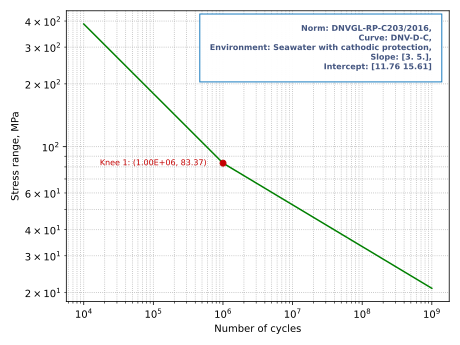

In [6]:
sn_cp = pf.SNCurve(
    slope=[3., 5.], 
    intercept=[11.764, 15.606], 
    environment = 'Seawater with cathodic protection', 
    curve = 'DNV-D-C', 
    norm ='DNVGL-RP-C203/2016',
    color='g'
)

sn_cp

Define and plot an SN curve for a D-detail in air environment using DNV guidelines 

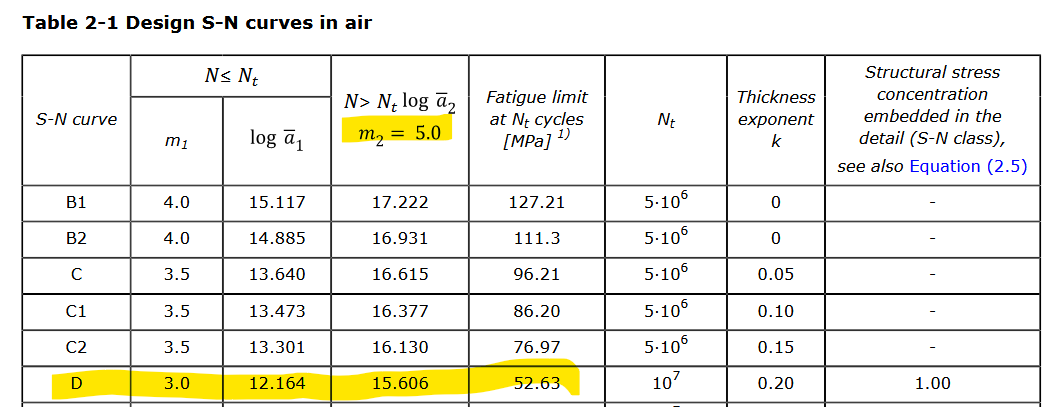

In [7]:
# Your code goes here



## *Paris Law*

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='SIF range (ΔK), MPa √mm', ylabel='Crack growth rate (da/dN), mm/cycle'>)

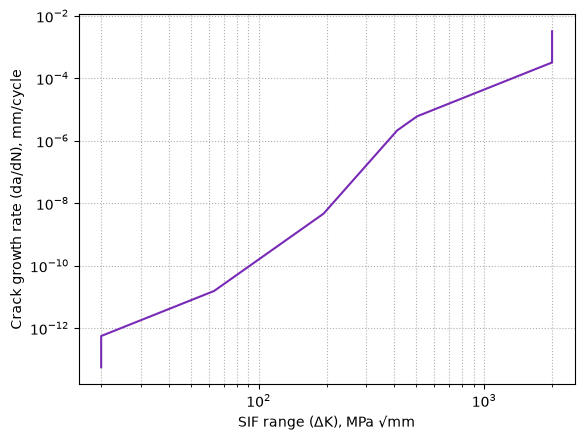

In [11]:
SIF = np.linspace(1,2500, 300)
SLOPE = np.array([2.88, 5.1, 8.16, 5.1, 2.88])
INTER = np.array([1E-16, 1E-20, 1E-27, 1E-19, 1E-13])
THRESHOLD = 20
CRITICAL = 2000
pc = pf.ParisCurve(slope=SLOPE, intercept=INTER, threshold=THRESHOLD,
                   critical=CRITICAL, norm="The norm",
                   environment="Environment", curve="nr.")

pc.plot()

In [9]:
# Demo load extrapolation factor (usually from design bending moment diagrams)
LEF = 3

# from standards
material_SF = 1.25

# Weld Stress concentration factors either from design or from as-built FEA analysis (can be max_scf, mean_scf or design_scf)
SCF_weld = 1.1

damage_Factor = LEF*SEF*material_SF*SCF_weld
print(damage_Factor)

2.0625
